In [ ]:
%%capture
! pip install laspy 

In [23]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

# File system operations
import os

# Return type hints
from typing import Tuple, List, Union


from scipy.spatial import KDTree
import scipy

import collections


In [2]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = (las.classification == filter_class)
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None


In [3]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)

In [4]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


In [5]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


In [6]:
def plot_z_distribution(points: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given points on a specific subplot, with outlier boundaries.
    """
    z_values = points[:, 2]  
    
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    
    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")
    
    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")
    
    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)



In [7]:
def preprocess_data(points: np.ndarray) -> np.ndarray:
    """
    Preprocess LiDAR points by shifting them and removing outliers based on the IQR method.
    """
    z_values = points[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)
    
    filtered_points = points[mask]
    
    return filtered_points


In [8]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)
    
    train_data = data[:split_idx]
    test_data = data[split_idx:]
    
    return train_data, test_data

In [9]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""
    
    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"
    
    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False 
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [21]:
def _array_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)

In [25]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    max_distance: float,
    max_height_difference: float
) -> list[dict]:
    """
    Match ground truth trees to candidate local maxima.
    """

    # 1) Distance matrix between GT points and candidate points
    dist_matrix = scipy.spatial.distance_matrix(
        ground_truth[:, :2],  # X,Y
        candidates[:, :2]     # X,Y
    )
    # Indices where distance <= max_distance
    i_gt, i_cand = np.nonzero(dist_matrix <= max_distance)
    distances = dist_matrix[i_gt, i_cand]

    # Combine into list of (distance, (gt_idx, cand_idx))
    pairs = sorted((d, (g, c)) for d, g, c in zip(distances, i_gt, i_cand))

    gt_matched = np.zeros(ground_truth.shape[0], dtype=bool)
    cand_matched = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    # 2) Iterate pairs in ascending distance
    for dist, (g, c) in pairs:
        # If already matched, skip
        if gt_matched[g] and cand_matched[c]:
            continue

        # Check height difference if both known
        if (
            not np.isnan(ground_truth[g, 2]) and
            abs(ground_truth[g, 2] - candidates[c, 2]) > max_height_difference
        ):
            continue

        # If GT was matched but candidate wasn't => candidate is FP
        if gt_matched[g] and not cand_matched[c]:
            cand_matched[c] = True
            out.append({
                "ground_truth": None,
                "candidate": _array_to_tuple(candidates[c]),
                "class": "FP",
                "distance": None,
            })
        # If candidate was matched but GT wasn't => GT is FN
        elif cand_matched[c] and not gt_matched[g]:
            gt_matched[g] = True
            out.append({
                "ground_truth": _array_to_tuple(ground_truth[g]),
                "candidate": None,
                "class": "FN",
                "distance": None,
            })
        else:
            # Both unmatched => True match => TP
            gt_matched[g] = True
            cand_matched[c] = True
            out.append({
                "ground_truth": _array_to_tuple(ground_truth[g]),
                "candidate": _array_to_tuple(candidates[c]),
                "class": "TP",
                "distance": dist,
            })

    # 3) Remaining unmatched GT points => FN
    for g_unmatched in np.where(~gt_matched)[0]:
        out.append({
            "ground_truth": _array_to_tuple(ground_truth[g_unmatched]),
            "candidate": None,
            "class": "FN",
            "distance": None,
        })

    # 4) Remaining unmatched candidates => FP
    for c_unmatched in np.where(~cand_matched)[0]:
        out.append({
            "ground_truth": None,
            "candidate": _array_to_tuple(candidates[c_unmatched]),
            "class": "FP",
            "distance": None,
        })

    return out

In [26]:
def calculate_match_metrics(matches: list[dict]) -> pd.Series:
    """
    Given a list of matches (from match_candidates),
    compute precision, recall, F1, and average distance for TP.
    """
    df = pd.DataFrame(matches)
    cls_counts = collections.Counter(df["class"])
    TP = cls_counts["TP"]
    FP = cls_counts["FP"]
    FN = cls_counts["FN"]

    # Avoid zero-division
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 0
    if (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)

    # Average distance among true positives
    # (ignore NaN if no TPs)
    avg_dist = df.loc[df["class"] == "TP", "distance"].mean() or 0.0

    return pd.Series({
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
        "avg_dist": round(avg_dist, 3),
    })

In [10]:
plot_las_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

### Preprocessing

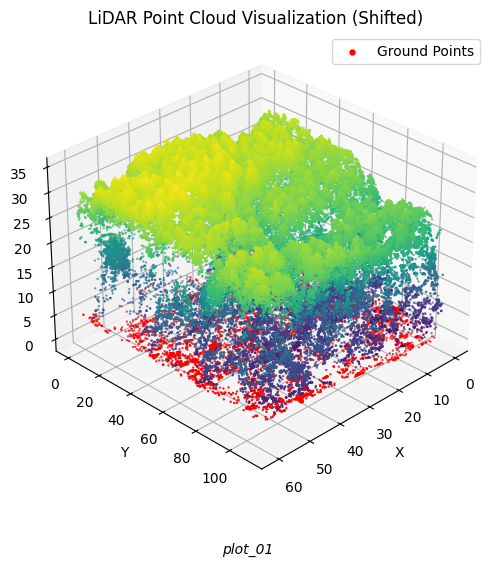

In [11]:
plot_shifted_lidar(plot_las_files[0])

Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


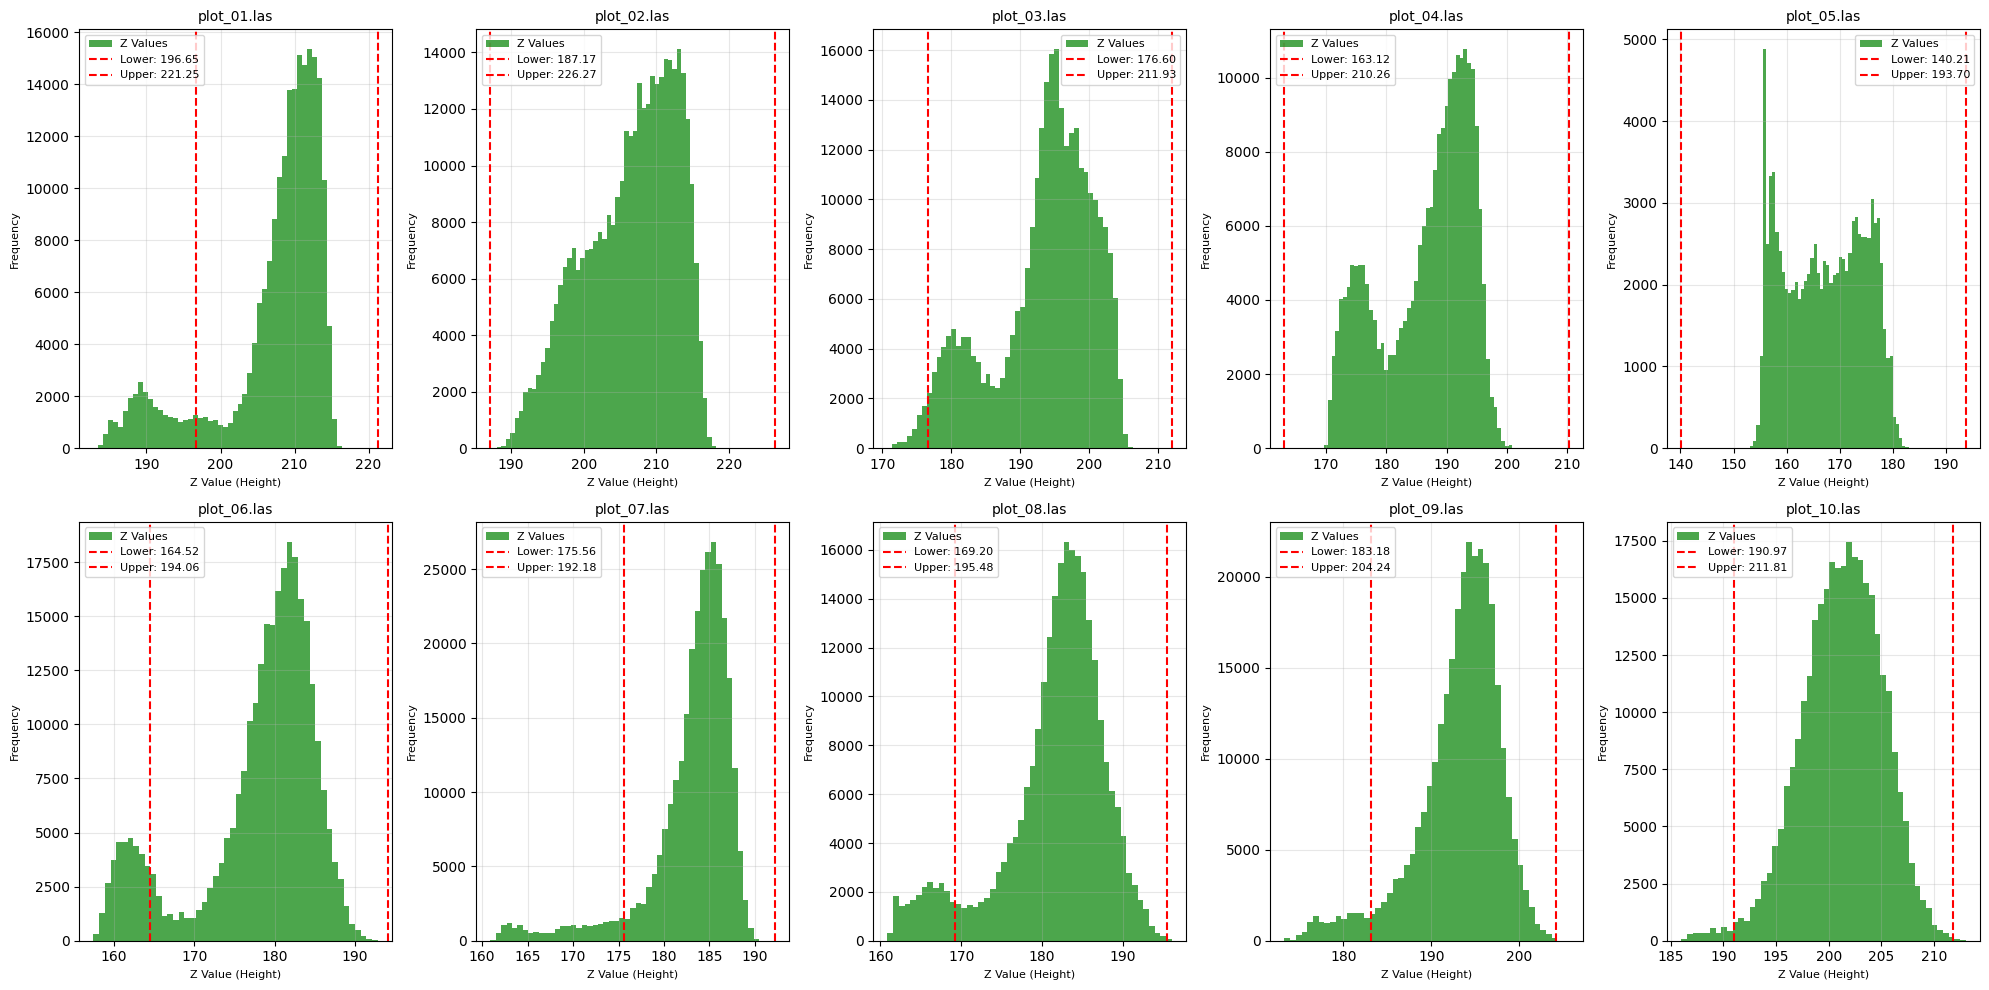

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
axes = axes.flatten()  

for i, file_path in enumerate(plot_las_files[:10]):  
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")
    
    # Load and filter points
    points = load_and_filter_las(file_path, filter_class=5)
    if points is None or len(points) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue
        
    plot_z_distribution(points, axes[i], file_name)


plt.tight_layout()
plt.show()


In [13]:
preprocessed_data = []  

for file_path in plot_las_files:
    
    points = load_and_filter_las(file_path, filter_class=5)
    
    if points is not None and len(points) > 0:
        preprocessed_points = preprocess_data(points)
        preprocessed_data.append(preprocessed_points)  
        
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 187731 preprocessed points
File 2: 350098 preprocessed points
File 3: 290624 preprocessed points
File 4: 241722 preprocessed points
File 5: 98878 preprocessed points
File 6: 255332 preprocessed points
File 7: 283645 preprocessed points
File 8: 234435 preprocessed points
File 9: 287341 preprocessed points
File 10: 307393 preprocessed points


### Split data into train and test

In [14]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

### Detection Method

In [15]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")

#### Local Maxima Filtering Algorithm

In [29]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

local_maxima_data = []

for i, points in enumerate(preprocessed_data):
    print(f"Processing training file {i + 1} with {len(points)} points...")
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")
    
    local_maxima_data.append(local_maxima_points)


Processing training file 1 with 187731 points...
Detected 243 local maxima in training file 1.
Processing training file 2 with 350098 points...
Detected 178 local maxima in training file 2.
Processing training file 3 with 290624 points...
Detected 255 local maxima in training file 3.
Processing training file 4 with 241722 points...
Detected 207 local maxima in training file 4.
Processing training file 5 with 98878 points...
Detected 241 local maxima in training file 5.
Processing training file 6 with 255332 points...
Detected 270 local maxima in training file 6.
Processing training file 7 with 283645 points...
Detected 157 local maxima in training file 7.
Processing training file 8 with 234435 points...
Detected 222 local maxima in training file 8.
Processing training file 9 with 287341 points...
Detected 181 local maxima in training file 9.
Processing training file 10 with 307393 points...
Detected 166 local maxima in training file 10.


In [31]:
# Thresholds for matching
max_distance = 5.0       
max_height_diff = 3.0    

results_list = []

for i, local_maxima_points in enumerate(local_maxima_data, start=1):

    plot_number = i  
    
    subset_gdf = field_survey_gpd[field_survey_gpd["plot"] == plot_number].copy()
    if subset_gdf.empty:
        print(f"No ground truth for plot {plot_number}. Skipping.")
        continue
    
    subset_gdf["x"] = subset_gdf.geometry.x
    subset_gdf["y"] = subset_gdf.geometry.y
    
    ground_truth_arr = subset_gdf[["x", "y", "height"]].to_numpy(dtype=float)
    
    # Match candidates (local maxima) to ground truth
    matches = match_candidates(
        ground_truth=ground_truth_arr,
        candidates=local_maxima_points,  
        max_distance=max_distance,
        max_height_difference=max_height_diff
    )
    
    metrics_series = calculate_match_metrics(matches)
    metrics_series["plot"] = plot_number
    
    results_list.append(metrics_series)
    
    print(f"Plot {plot_number} => {metrics_series.to_dict()}")

results_df = pd.DataFrame(results_list).set_index("plot")


Plot 1 => {'precision': 0.593, 'recall': 0.343, 'f1': 0.434, 'avg_dist': 0.988, 'plot': 1.0}
Plot 2 => {'precision': 0.489, 'recall': 0.238, 'f1': 0.32, 'avg_dist': 1.542, 'plot': 2.0}
Plot 3 => {'precision': 0.404, 'recall': 0.31, 'f1': 0.351, 'avg_dist': 1.42, 'plot': 3.0}
Plot 4 => {'precision': 0.396, 'recall': 0.314, 'f1': 0.35, 'avg_dist': 1.71, 'plot': 4.0}
Plot 5 => {'precision': 0.32, 'recall': 0.37, 'f1': 0.343, 'avg_dist': 1.409, 'plot': 5.0}
Plot 6 => {'precision': 0.426, 'recall': 0.397, 'f1': 0.411, 'avg_dist': 1.099, 'plot': 6.0}
Plot 7 => {'precision': 0.611, 'recall': 0.235, 'f1': 0.34, 'avg_dist': 1.369, 'plot': 7.0}
Plot 8 => {'precision': 0.514, 'recall': 0.334, 'f1': 0.405, 'avg_dist': 1.219, 'plot': 8.0}
Plot 9 => {'precision': 0.564, 'recall': 0.222, 'f1': 0.319, 'avg_dist': 1.126, 'plot': 9.0}
Plot 10 => {'precision': 0.62, 'recall': 0.199, 'f1': 0.301, 'avg_dist': 1.178, 'plot': 10.0}


In [32]:
print("\nFinal per-plot metrics:")
print(results_df)

print("\nAverage metrics across all plots:")
print(results_df.mean(numeric_only=True))


Final per-plot metrics:
      precision  recall     f1  avg_dist
plot                                    
1.0       0.593   0.343  0.434     0.988
2.0       0.489   0.238  0.320     1.542
3.0       0.404   0.310  0.351     1.420
4.0       0.396   0.314  0.350     1.710
5.0       0.320   0.370  0.343     1.409
6.0       0.426   0.397  0.411     1.099
7.0       0.611   0.235  0.340     1.369
8.0       0.514   0.334  0.405     1.219
9.0       0.564   0.222  0.319     1.126
10.0      0.620   0.199  0.301     1.178

Average metrics across all plots:
precision    0.4937
recall       0.2962
f1           0.3574
avg_dist     1.3060
dtype: float64


#### Convert Point Cloud to Voxel Grid

#### Advanced DNN architecture

### Comparison